In [44]:
!pip install dgeb datasets -q
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from itertools import product
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import average_precision_score

#1. Load Dataset

In [45]:
from datasets import load_dataset

# Dataset Link: https://huggingface.co/tattabio/datasets?p=0
ecoli  = load_dataset("tattabio/ecoli_operonic_pair")
cyano  = load_dataset("tattabio/cyano_operonic_pair")
vibrio = load_dataset("tattabio/vibrio_operonic_pair")

print("E. coli columns:", ecoli["train"].features)
print("Cyano columns:",   cyano["train"].features)
print("Vibrio columns:",  vibrio["train"].features)

E. coli columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}
Cyano columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}
Vibrio columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}


#2. Build Gene Pairs

In [46]:

def build_pairs(dataset_split):
    seqs   = dataset_split["Sequence"]
    labels = dataset_split["Label"]

    seq_a, seq_b, pair_labels = [], [], []
    for i in range(len(seqs) - 1):
        seq_a.append(seqs[i])
        seq_b.append(seqs[i + 1])
        pair_labels.append(labels[i])

    return seq_a, seq_b, np.array(pair_labels)

seq_a_ec, seq_b_ec, labels_ec = build_pairs(ecoli["train"])
seq_a_cy, seq_b_cy, labels_cy = build_pairs(cyano["train"])
seq_a_vi, seq_b_vi, labels_vi = build_pairs(vibrio["train"])

print(f"E. coli pairs: {len(labels_ec):,}, positive rate: {labels_ec.mean():.1%}")
print(f"Cyano pairs:   {len(labels_cy):,}, positive rate: {labels_cy.mean():.1%}")
print(f"Vibrio pairs:  {len(labels_vi):,}, positive rate: {labels_vi.mean():.1%}")

E. coli pairs: 4,314, positive rate: 40.5%
Cyano pairs:   2,610, positive rate: 28.2%
Vibrio pairs:  2,573, positive rate: 34.6%


In [47]:
print(ecoli["train"]["Label"][:10])

[1, 1, 1, 0, 0, 0, 0, 0, 0, 0]


#3. K-mer + Train/Test Split + PCA

In [48]:
AA = "ACDEFGHIKLMNPQRSTVWY"
KMERS = {"".join(p): i for i, p in enumerate(product(AA, repeat=3))}

def kmer_vector(seq, k=3):
    """Convert amino acid sequence to normalized k-mer frequency vector."""
    vec = np.zeros(len(KMERS), dtype=np.float32)
    seq = seq.upper()
    count = 0
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in KMERS:
            vec[KMERS[kmer]] += 1
            count += 1
    if count > 0:
        vec /= count
    return vec

def encode_pairs(seq_a_list, seq_b_list, label=""):
    print(f"Encoding {label} sequences")
    vA = np.array([kmer_vector(s) for s in seq_a_list])
    vB = np.array([kmer_vector(s) for s in seq_b_list])
    X  = np.concatenate([vA, vB, np.abs(vA - vB)], axis=1)
    print(f"Done. Shape: {X.shape}")
    return X

X_ec = encode_pairs(seq_a_ec, seq_b_ec, "E. coli")
X_cy = encode_pairs(seq_a_cy, seq_b_cy, "Cyano")
X_vi = encode_pairs(seq_a_vi, seq_b_vi, "Vibrio")

Encoding E. coli sequences
Done. Shape: (4314, 24000)
Encoding Cyano sequences
Done. Shape: (2610, 24000)
Encoding Vibrio sequences
Done. Shape: (2573, 24000)


In [49]:
from sklearn.model_selection import train_test_split

X_ec_train, X_ec_test, y_ec_train, y_ec_test = train_test_split(
    X_ec, labels_ec, test_size=0.2, stratify=labels_ec, random_state=42
)
X_cy_train, X_cy_test, y_cy_train, y_cy_test = train_test_split(
    X_cy, labels_cy, test_size=0.2, stratify=labels_cy, random_state=42
)
X_vi_train, X_vi_test, y_vi_train, y_vi_test = train_test_split(
    X_vi, labels_vi, test_size=0.2, stratify=labels_vi, random_state=42
)

print(f"E. coli  — train: {X_ec_train.shape[0]:,}  test: {X_ec_test.shape[0]:,}")
print(f"Cyano    — train: {X_cy_train.shape[0]:,}  test: {X_cy_test.shape[0]:,}")
print(f"Vibrio   — train: {X_vi_train.shape[0]:,}  test: {X_vi_test.shape[0]:,}")

E. coli  — train: 3,451  test: 863
Cyano    — train: 2,088  test: 522
Vibrio   — train: 2,058  test: 515


In [62]:
pca = PCA(n_components=200, random_state=42)
pca.fit(X_ec_train)

print(f"Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

X_ec_train_pca = pca.transform(X_ec_train)
X_ec_test_pca  = pca.transform(X_ec_test)
X_cy_train_pca = pca.transform(X_cy_train)
X_cy_test_pca  = pca.transform(X_cy_test)
X_vi_train_pca = pca.transform(X_vi_train)
X_vi_test_pca  = pca.transform(X_vi_test)

Variance explained: 95.0%


#4. Complement Naive Bayes (CNB)

In [51]:
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import cross_val_score

alphas = [0.01, 0.1, 0.5, 1.0]
best_alpha = None
best_ap = -1
cnb_scores = []

print("ComplementNB alpha search")
for alpha in alphas:
    model = ComplementNB(alpha=alpha)
    cv_scores = cross_val_score(
        model, X_ec_train, y_ec_train, cv=5, scoring="average_precision"
    )
    avg_ap = cv_scores.mean()
    cnb_scores.append(avg_ap)   # ← accumulate
    print("alpha:", alpha, "mean AP:", round(avg_ap, 4))
    if avg_ap > best_ap:
        best_ap = avg_ap
        best_alpha = alpha

print()
print("Best alpha:", best_alpha)
print("Best CV average precision:", round(best_ap, 4))

ComplementNB alpha search
alpha: 0.01 mean AP: 0.5297
alpha: 0.1 mean AP: 0.4927
alpha: 0.5 mean AP: 0.4482
alpha: 1.0 mean AP: 0.4361

Best alpha: 0.01
Best CV average precision: 0.5297


#5. Logistic Regression

In [52]:
Cs = [0.01, 0.1, 1, 10, 100]
best_C = None
best_ap = -1
lr_scores = []

print("Logistic Regression C search")
for C in Cs:
    model = LogisticRegression(
        C=C, penalty="l2", solver="lbfgs", max_iter=1000, random_state=42
    )
    cv_scores = cross_val_score(
        model, X_ec_train, y_ec_train, cv=5, scoring="average_precision"
    )
    avg_ap = cv_scores.mean()
    lr_scores.append(avg_ap)
    print("C:", C, "mean AP:", round(avg_ap, 4))
    if avg_ap > best_ap:
        best_ap = avg_ap
        best_C = C

print()
print("Best C:", best_C)
print("Best CV average precision:", round(best_ap, 4))

Logistic Regression C search
C: 0.01 mean AP: 0.4656
C: 0.1 mean AP: 0.5349
C: 1 mean AP: 0.5349
C: 10 mean AP: 0.5349
C: 100 mean AP: 0.5344

Best C: 10
Best CV average precision: 0.5349


#6. Random Forest

In [53]:
n_estimators_list = [100, 200, 500]
max_features_list = ["sqrt", "log2", 0.1]
best_n = None
best_mf = None
best_ap_rf = -1
rf_grid_scores = np.zeros((3, 3))

print("Random Forest n_estimators and max_features search")
for i, n_est in enumerate(n_estimators_list):
    for j, mf in enumerate(max_features_list):
        model = RandomForestClassifier(
            n_estimators=n_est,
            max_features=mf,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
        cv_scores = cross_val_score(
            model, X_ec_train_pca, y_ec_train, cv=5, scoring="average_precision"
        )
        avg_ap = cv_scores.mean()
        rf_grid_scores[i, j] = avg_ap
        print("n_estimators:", n_est, "max_features:", mf, "mean AP:", round(avg_ap, 4))
        if avg_ap > best_ap_rf:
            best_ap_rf = avg_ap
            best_n = n_est
            best_mf = mf

print()
print("Best n_estimators:", best_n)
print("Best max_features:", best_mf)
print("Best CV average precision:", round(best_ap_rf, 4))

Random Forest n_estimators and max_features search
n_estimators: 100 max_features: sqrt mean AP: 0.5261
n_estimators: 100 max_features: log2 mean AP: 0.5327
n_estimators: 100 max_features: 0.1 mean AP: 0.5319
n_estimators: 200 max_features: sqrt mean AP: 0.5376
n_estimators: 200 max_features: log2 mean AP: 0.5397
n_estimators: 200 max_features: 0.1 mean AP: 0.5428
n_estimators: 500 max_features: sqrt mean AP: 0.5478
n_estimators: 500 max_features: log2 mean AP: 0.5426
n_estimators: 500 max_features: 0.1 mean AP: 0.5506

Best n_estimators: 500
Best max_features: 0.1
Best CV average precision: 0.5506


#7. Training

In [54]:
def train_and_evaluate(model):
    results = {}
    datasets = [
        ("E. coli", X_ec_train, y_ec_train, X_ec_test, y_ec_test),
        ("Cyano", X_cy_train, y_cy_train, X_cy_test, y_cy_test),
        ("Vibrio", X_vi_train, y_vi_train, X_vi_test, y_vi_test),
    ]
    for name, X_train, y_train, X_test, y_test in datasets:
        model.fit(X_train, y_train)
        y_score = model.predict_proba(X_test)[:, 1]
        ap = average_precision_score(y_test, y_score)
        results[name] = round(ap, 4)
    return results

def train_and_evaluate_rf(model):
    results = {}
    datasets = [
        ("E. coli", X_ec_train_pca, y_ec_train, X_ec_test_pca, y_ec_test),
        ("Cyano",   X_cy_train_pca, y_cy_train, X_cy_test_pca, y_cy_test),
        ("Vibrio",  X_vi_train_pca, y_vi_train, X_vi_test_pca, y_vi_test),
    ]
    for name, X_train, y_train, X_test, y_test in datasets:
        model.fit(X_train, y_train)
        y_score = model.predict_proba(X_test)[:, 1]
        ap = average_precision_score(y_test, y_score)
        results[name] = round(ap, 4)
    return results

best_alpha_cnb = 0.01
best_C_lr = 10

cnb_model = ComplementNB(alpha=best_alpha_cnb)
lr_model = LogisticRegression(
    C=best_C_lr,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
rf_model = RandomForestClassifier(
    n_estimators=best_n,
    max_features=best_mf,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

cnb_results = train_and_evaluate(cnb_model)
lr_results  = train_and_evaluate(lr_model)
rf_results  = train_and_evaluate_rf(rf_model)

print("CNB results:", cnb_results)
print("Logistic Regression results:", lr_results)
print("Random Forest results:", rf_results)

CNB results: {'E. coli': np.float64(0.4884), 'Cyano': np.float64(0.3271), 'Vibrio': np.float64(0.4555)}
Logistic Regression results: {'E. coli': np.float64(0.5024), 'Cyano': np.float64(0.3204), 'Vibrio': np.float64(0.4636)}
Random Forest results: {'E. coli': np.float64(0.4965), 'Cyano': np.float64(0.3457), 'Vibrio': np.float64(0.4224)}


In [55]:
dgeb_baselines = {
    "E. coli": {
        "ESM2-650M": 0.573,
        "ESM3": 0.577,
        "ProtTrans": 0.618
    },
    "Cyano": {
        "ESM2-650M": 0.373,
        "ESM3": 0.390,
        "ProtTrans": 0.409
    },
    "Vibrio": {
        "ESM2-650M": 0.483,
        "ESM3": 0.497,
        "ProtTrans": 0.543
    }
}

rows = []
for dataset in ["E. coli", "Cyano", "Vibrio"]:
    rows.append({
        "Dataset": dataset,
        "CNB": cnb_results[dataset],
        "Logistic Regression": lr_results[dataset],
        "Random Forest": rf_results[dataset],
        "ESM2-650M": dgeb_baselines[dataset]["ESM2-650M"],
        "ESM3": dgeb_baselines[dataset]["ESM3"],
        "ProtTrans": dgeb_baselines[dataset]["ProtTrans"]
    })

results_df = pd.DataFrame(rows)
results_df = results_df.set_index("Dataset")
print()
print("Average precision comparison")
print(results_df.to_string())


Average precision comparison
            CNB  Logistic Regression  Random Forest  ESM2-650M   ESM3  ProtTrans
Dataset                                                                         
E. coli  0.4884               0.5024         0.4965      0.573  0.577      0.618
Cyano    0.3271               0.3204         0.3457      0.373  0.390      0.409
Vibrio   0.4555               0.4636         0.4224      0.483  0.497      0.543


#8. Hyperparamters Plots

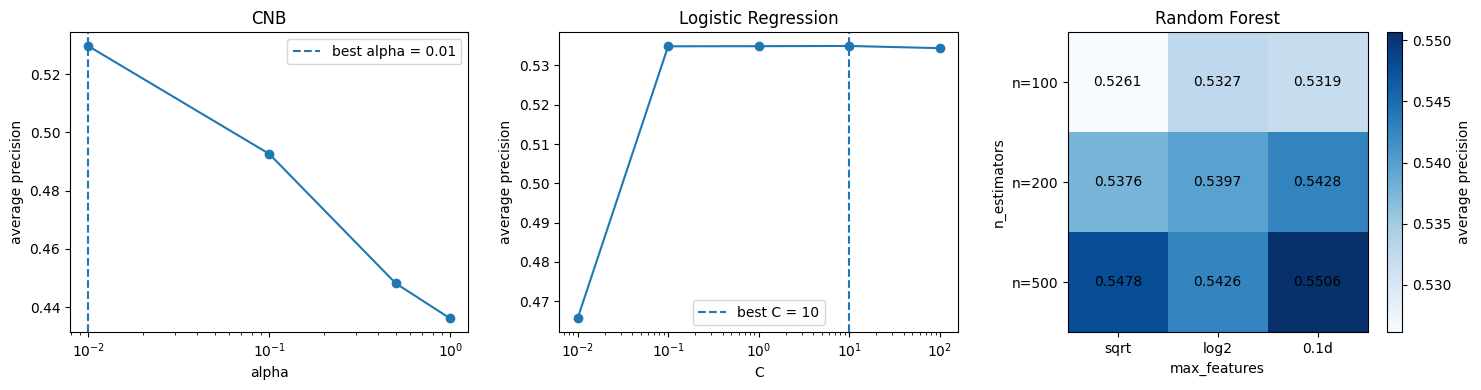

In [56]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# CNB
ax1.plot(alphas, cnb_scores, marker="o")
ax1.axvline(best_alpha, linestyle="--", label=f"best alpha = {best_alpha}")
ax1.set_xscale("log")
ax1.set_xlabel("alpha")
ax1.set_ylabel("average precision")
ax1.set_title("CNB")
ax1.legend()

# Logistic Regression
ax2.plot(Cs, lr_scores, marker="o")
ax2.axvline(best_C, linestyle="--", label=f"best C = {best_C}")
ax2.set_xscale("log")
ax2.set_xlabel("C")
ax2.set_ylabel("average precision")
ax2.set_title("Logistic Regression")
ax2.legend()

# Random Forest heatmap
im = ax3.imshow(rf_grid_scores, cmap="Blues")
ax3.set_xticks(range(3))
ax3.set_yticks(range(3))
ax3.set_xticklabels(["sqrt", "log2", "0.1d"])
ax3.set_yticklabels(["n=100", "n=200", "n=500"])
ax3.set_xlabel("max_features")
ax3.set_ylabel("n_estimators")
ax3.set_title("Random Forest")
for i in range(3):
    for j in range(3):
        ax3.text(j, i, round(rf_grid_scores[i, j], 4), ha="center", va="center")
plt.colorbar(im, ax=ax3, label="average precision")

plt.tight_layout()
plt.savefig("hyperparameter_search.png", dpi=150)
plt.show()

#9. K-mer vs. Baseline

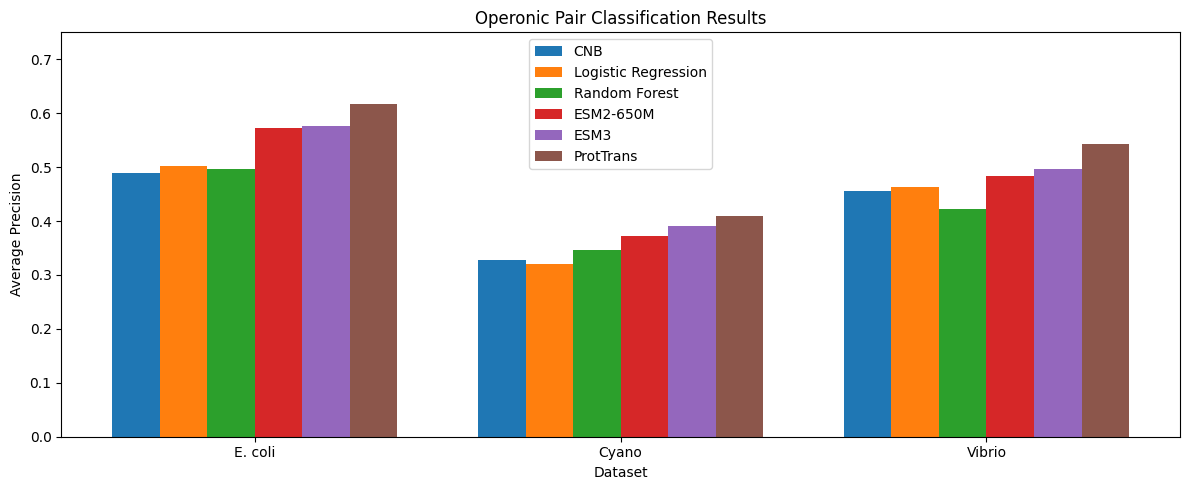

In [57]:
datasets = ['E. coli', 'Cyano', 'Vibrio']
methods = {
    "CNB":                [cnb_results["E. coli"], cnb_results["Cyano"], cnb_results["Vibrio"]],
    "Logistic Regression":[lr_results["E. coli"],  lr_results["Cyano"],  lr_results["Vibrio"]],
    "Random Forest":      [rf_results["E. coli"],  rf_results["Cyano"],  rf_results["Vibrio"]],
    "ESM2-650M":          [0.573, 0.373, 0.483],
    "ESM3":               [0.577, 0.390, 0.497],
    "ProtTrans":          [0.618, 0.409, 0.543],
}

x = np.arange(len(datasets))
width = 0.13

plt.figure(figsize=(12, 5))
for i, (method, scores) in enumerate(methods.items()):
    plt.bar(x + i * width, scores, width, label=method)

plt.xlabel("Dataset")
plt.ylabel("Average Precision")
plt.title("Operonic Pair Classification Results")
plt.xticks(x + width * 2.5, datasets)
plt.ylim(0, 0.75)
plt.legend()
plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()

#10. All Representations vs. Baseline

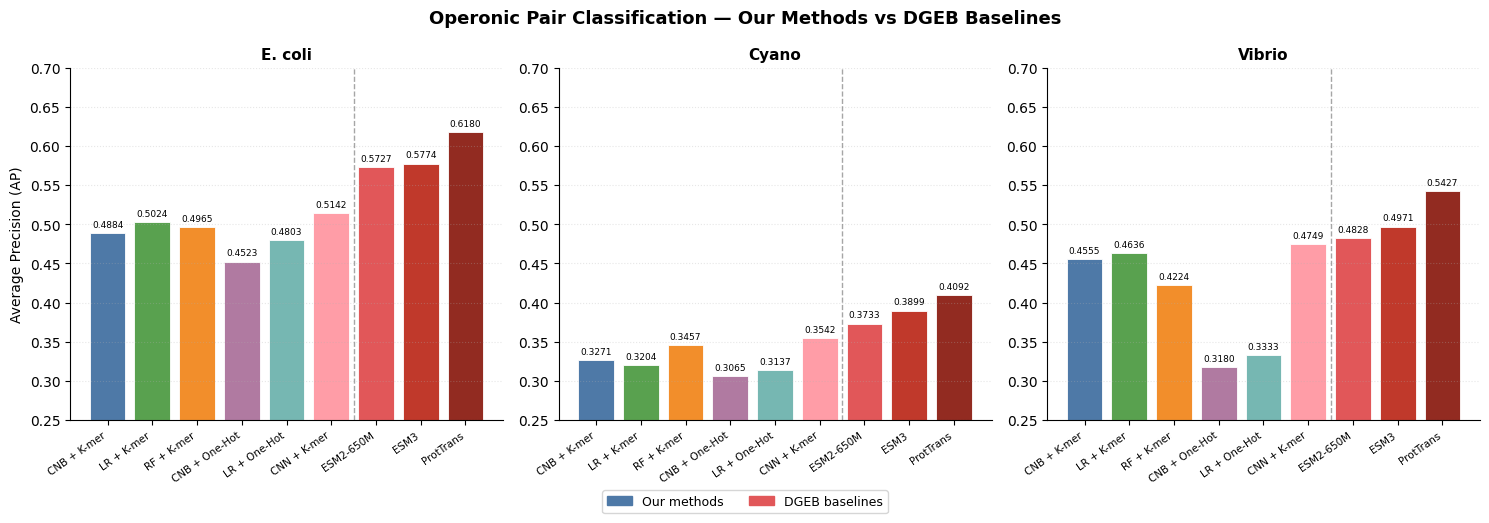

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


datasets = ["E. coli", "Cyano", "Vibrio"]

our_methods = {
    "CNB + K-mer":   [0.4884, 0.3271, 0.4555],
    "LR + K-mer":    [0.5024, 0.3204, 0.4636],
    "RF + K-mer":    [0.4965, 0.3457, 0.4224],
    "CNB + One-Hot": [0.4523, 0.3065, 0.3180],
    "LR + One-Hot":  [0.4803, 0.3137, 0.3333],
    "CNN + K-mer":   [0.5142, 0.3542, 0.4749],
}

dgeb_methods = {
    "ESM2-650M": [0.5727, 0.3733, 0.4828],
    "ESM3":      [0.5774, 0.3899, 0.4971],
    "ProtTrans": [0.6180, 0.4092, 0.5427],
}

our_colors  = ["#4E79A7", "#59A14F", "#F28E2B", "#B07AA1", "#76B7B2", "#FF9DA7"]
dgeb_colors = ["#E15759", "#C0392B", "#922B21"]

all_methods = {**our_methods, **dgeb_methods}
all_colors  = our_colors + dgeb_colors

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle("Operonic Pair Classification — Our Methods vs DGEB Baselines",
             fontsize=13, fontweight="bold")

x      = np.arange(len(all_methods))
labels = list(all_methods.keys())

for ax, dataset, ds_idx in zip(axes, datasets, range(3)):
    scores = [v[ds_idx] for v in all_methods.values()]
    bars   = ax.bar(x, scores, color=all_colors, edgecolor="white", linewidth=0.6)

    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=6.5)

    ax.axvline(x=len(our_methods) - 0.5, color="gray",
               linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(dataset, fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=7.5)
    ax.set_ylim(0.25, 0.70)
    ax.set_ylabel("Average Precision (AP)" if ds_idx == 0 else "")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle=":")

our_patch  = mpatches.Patch(color="#4E79A7", label="Our methods")
dgeb_patch = mpatches.Patch(color="#E15759", label="DGEB baselines")
fig.legend(handles=[our_patch, dgeb_patch], loc="lower center",
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()